<b>Group Number:</b>  8
<br><b>Name Group Member 1:</b>  Arne Segatz
<br><b>u-Kürzel Group Member 1:</b>  urnye
<br><b>Name Group Member 2:</b> Anton Seifert 
<br><b>u-Kürzel Group Member 2:</b> unjud 

In [2]:
# Imports
# NOTE: Before you can do this task, you have to install gensim to your environment.
import gensim.downloader
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interactive, Layout
import ipywidgets as widgets
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

c:\Users\arnes\miniconda3\envs\lama25-env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Task 7.2: Transformers

"AI" is currently experiencing an ongoing boom that arguably started in the late 2010s. Tools like DALL-E, Sora and of course ChatGPT have been widely adopted by the general public and offer a level of quality previously thought impossible or at least implausible. The mechanism underlying these tools is the transformer architecture with multi-head attention, developed at Google and published in the paper ["Attention Is All You Need" (Vaswani et al., 2017)](https://doi.org/10.48550/arXiv.1706.03762). The large language model that we will use as a guiding example gets a snippet of text as its input and tries to **predict which word comes next**. To do this, it has to understand each individual word in the context of all the other words. This contextualization is what attention is all about.

In the following sections you will learn what exactly a transformer is and how the attention mechanism works, hopefully gaining an intuitive understanding of how data flows through a transformer and how a chat-bot comes up with its answers. We will use GPT-3 as a guiding example, because it is arguably the first LLM to get mainstream attention. In the picture below, you can see an overview of the transformer architecture as it was published in 2017. Don't worry if it looks intimidating, we will explain it step-by-step. 

<p align="center">
  <img src="images/transformer_overview.png" width="30%" height="auto"/>
  <br>
  <em>Figure 1: Overview over the structure of a transformer. </em>
</p>

## Embedding

As you can see, the first step the input data experiences is called "Input Embedding", so let's start with that. As you know by now, machine learning models don't process words the same way as humans. Instead, they operate on vectors of real numbers. Every word that a large language model "knows" has to be uniquely represented by such a vector, also called the $\textit{embedding}$ of a word. In the previous task on LSTMs, you learned that these "words" we speak of are actually called tokens. Tokens are either short constellations of characters that appears often, or individual characters. Tokenization is necessary because it greatly decreases the total number of words (...tokens) that a LLM has to know, called $\textit{vocabulary size}$. GPT-3 has a vocabulary size of 50257. For the sake of clarity, let us pretend that whole words are embedded, instead of tokens.

In the case of GPT-3, the size of each embedding vector is 12288. Algebraically, the embedding operation can be thought of as picking a column out of an embedding matrix $W_{E}$ for each word. From this it follows that the embedding matrix has 50257 columns (one for each word) and 12288 rows (the embedding size). It is intuitive that the embedding of a word has to somehow encode the meaning of that word into a mathematical object. The weights of the embedding matrix are therefore learned from data, such that **the position in the embedding space corresponds to the meaning of the embedded word**. 

12288 dimensions are of course a little too many for humans to visualize, but we can still play around with this idea by remembering the characteristics of the dot product (Skalarprodukt) from math class. Remember that the dot product of two vectors becomes larger as the vectors align with each other! This holds true even in higher dimensional spaces, so we will use it to explore the embedding space of a LLM.

<div class="alert alert-block alert-info">
<b>Note:</b> The following interactive plot is meant as a quick refresher on the dot product. Use the slider to change the direction of one of the vectors and see how the dot product changes. Feel free to skip ahead if you are already familiar with this concept. 

</div>

In [ ]:
def visualize_dot_product(angle_degrees):
    vec1 = np.array([1, 0])
    angle_radians = np.radians(angle_degrees)
    vec2 = np.array([np.cos(angle_radians), np.sin(angle_radians)])
    dot_product = np.dot(vec1, vec2)

    plt.figure(figsize=(6, 6))
    plt.quiver(0, 0, vec1[0], vec1[1], angles='xy', scale_units='xy', scale=1, color='blue', label='Vector 1')
    plt.quiver(0, 0, vec2[0], vec2[1], angles='xy', scale_units='xy', scale=1, color='red', label='Vector 2')
    plt.xlim(-1.5, 1.5)
    plt.ylim(-1.5, 1.5)
    plt.grid(True)
    plt.axhline(0, color='black',linewidth=1)
    plt.axvline(0, color='black',linewidth=1)
    plt.title(f"Dot Product: {dot_product:.2f}\nAngle: {angle_degrees}°")
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.legend()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

# Slider
slider_layout = Layout(width="90%")
angle_slider = widgets.IntSlider(value=0, min=0, max=360, step=1, description='Angle (°)', layout=slider_layout)
interactive_plot = interactive(visualize_dot_product, angle_degrees=angle_slider)
# Plot
interactive_plot

interactive(children=(IntSlider(value=0, description='Angle (°)', layout=Layout(width='90%'), max=360), Output…



In the following code blocks, we make use of an exemplary embedding matrix that has already been trained, to explore the embedding space. Feel free to play around with the embedding space to familiarize yourself with the concept of **direction representing semantic meaning**.

In [4]:
# Download the trained embedding matrix
embedder = gensim.downloader.load('glove-wiki-gigaword-50')

In [5]:
# You can get word embeddings (vectors) by indexing the embedder object like a list
man_emb = embedder['man']
woman_emb = embedder['woman']

# You can find the n most similar words by key or by vector
key = 'car'
similar_to_car = embedder.similar_by_key(key, topn=5)
print(f'Words most similar to \"{key}\":', [x[0] for x in similar_to_car])

# Or you can compute similarites manually
cat_emb = embedder['cat']
dog_emb = embedder['dog']
monster_emb = embedder['monster']

# NOTE: When computing the similarity of two embeddings, we can divide by the length of the vectors to ensure that we only factor in their direction (also called "Cosine Similarity")
print('Similarity of \"cat\" and \"monster\":', np.dot(cat_emb, monster_emb)/(np.linalg.norm(cat_emb)*np.linalg.norm(monster_emb)))
print('Similarity of \"dog\" and \"monster\":', np.dot(dog_emb, monster_emb)/(np.linalg.norm(dog_emb)*np.linalg.norm(monster_emb)))

Words most similar to "car": ['truck', 'cars', 'vehicle', 'driver', 'driving']
Similarity of "cat" and "monster": 0.76197624
Similarity of "dog" and "monster": 0.7105766


In [8]:
# You may use this code block to play with the embedding space (optional).
key = 'house'
similar_to_house = embedder.similar_by_key(key, topn=5)
print(f'Words most similar to \"{key}\":', [x[0] for x in similar_to_house])

Words most similar to "house": ['office', 'capitol', 'new', 'building', 'senate']


<div class="alert alert-block alert-success">
<b>Question (2 pts):</b> Read the following code block and its output graph carefully. Explain in your own words what experiment has been performed and what the results tell us about the embedding space of a LLM.
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> Das Experiment zeigt, dass durch die Subtraktion der Vektoren cats-cat erhält man eine Vektor der die Unterschiede zwischen Plural und Singular beschreibt. Wenn man diesen Vektor mit Singularwörter und Pluralwörter vergleicht, sind die Pluralwörter ihm ähnlich und die Singularwörter nicht. Das Ergebnis zeigt, dass der Embedding-Raum eines LLM grammatische Eigenschaften wie Singular und Plural systematisch und konsistent als Richtungen im Vektorraum repräsentiert.



</div>

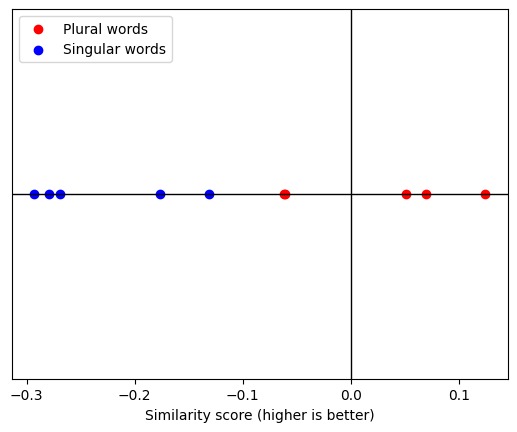

In [6]:
# Mystery Experiment
plural = embedder['cats'] - embedder['cat']

plural_words = ['tables', 'kids', 'trees', 'dogs', 'devices']
singular_words = ['table', 'kid', 'tree', 'dog', 'device']
plural_words_emb = [embedder[x] for x in plural_words]
singular_words_emb = [embedder[x] for x in singular_words]

similarites_plural = [np.dot(plural, x)/(np.linalg.norm(plural)*np.linalg.norm(x)) for x in plural_words_emb]
similarites_singular = [np.dot(plural, x)/(np.linalg.norm(plural)*np.linalg.norm(x)) for x in singular_words_emb]

# Generate a plot
plt.scatter(x=similarites_plural, y=[0]*len(similarites_plural), c='red', label='Plural words')
plt.scatter(x=similarites_singular, y=[0]*len(similarites_singular), c='blue', label='Singular words')
plt.xlabel("Similarity score (higher is better)")
plt.yticks([])
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.legend()

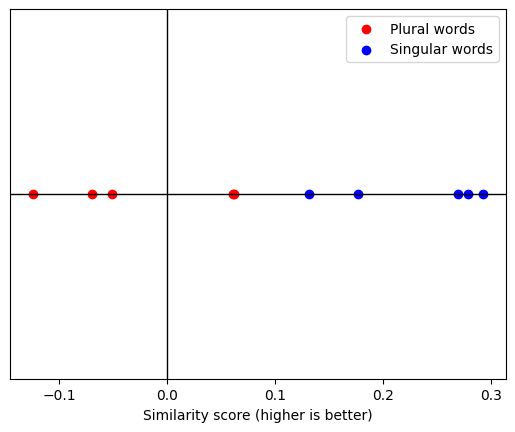

In [10]:
#Test Experiment 
plural =  embedder['cat']- embedder['cats']

plural_words = ['tables', 'kids', 'trees', 'dogs', 'devices']
singular_words = ['table', 'kid', 'tree', 'dog', 'device']
plural_words_emb = [embedder[x] for x in plural_words]
singular_words_emb = [embedder[x] for x in singular_words]

similarites_plural = [np.dot(plural, x)/(np.linalg.norm(plural)*np.linalg.norm(x)) for x in plural_words_emb]
similarites_singular = [np.dot(plural, x)/(np.linalg.norm(plural)*np.linalg.norm(x)) for x in singular_words_emb]

# Generate a plot
plt.scatter(x=similarites_plural, y=[0]*len(similarites_plural), c='red', label='Plural words')
plt.scatter(x=similarites_singular, y=[0]*len(similarites_singular), c='blue', label='Singular words')
plt.xlabel("Similarity score (higher is better)")
plt.yticks([])
plt.axhline(0, color='black',linewidth=1)
plt.axvline(0, color='black',linewidth=1)
plt.legend()

### Positional Encoding

In addition to the embedding of the individual words of an input sequence, the model also receives a **positional encoding**. As you learned just now, the embedding matrix is just a one-to-one mapping of words to vectors, it doesn't take the order of the input sequence into account. Without positional encoding, the input sequences "A man pets his dog in the garden." and "A garden pets his dog in the man." would be treated equally. Multiple strategies exist for positional encoding, but we will not go into further detail how they work. If you are interested in learning more about positional encoding, check out [this](https://medium.com/@xuer.chen.human/llm-study-notes-positional-encoding-0639a1002ec0) article. In short, the positional encoding is a vector of the same length as the embedding size. It is simply added to its corresponding embedding vector for each input word.


### Context size

Contrary to the toy examples we will discuss in the next section, the input size to a LLM is actually fixed. It is called the context size and it simultaneously describes the largest distance of input tokens over which information can be passed. For any input sequence that is smaller than the context size, the remaining space is filled with special tokens to artificially lengthen the sequence to the correct size. For GPT-3 the context size is 2048.

## The Attention Mechanism

Now that we have transformed our input sequence of words into an input sequence of embedding vectors, we must somehow transfer information between each vector. Consider the following example to understand why this is necessary:

**Context 1: Financial institution**

- **Sentence:** "I need to go to the bank to withdraw cash."
- **Meaning:** Here, "bank" refers to a financial institution where people manage their money.

**Context 2: Geographical place**

- **Sentence:** "We had a picnic on the bank of the river."
- **Meaning:** In this context, "bank" refers to the land alongside a river.

The word "bank" has completely different meanings, depending on the context it is used in. But for now, our embedding does not take context into account, as each word is embedded separately. So for both contexts, the embedding vector for the word "bank" would be the same. What we want the attention mechanism to do, is to somehow **update the embedding vector of each word, based on the words in its surroundings** to better reflect the meaning in the given context. This means that the direction that a word points to in the embedding space will change based on the surrounding words that are important to its meaning.



### Single Attention Head

Let's start with a single attention block. Each attention block contains three matrices, called *Query*, *Key* and *Value*. We can denote them with $W_{Q}$, $W_{K}$ and $W_{V}$. We will denote the input sequence of embedding vectors with $\overrightarrow{E}_{1}$, $\overrightarrow{E}_{2}$, ..., $\overrightarrow{E}_{n}$.

Each embedding vector of the input sequence is multiplied with the query matrix $W_{Q}$, producing a new sequence of vectors that we call query vectors $\overrightarrow{Q}_{1}$, $\overrightarrow{Q}_{2}$, ..., $\overrightarrow{Q}_{n}$. This operation can be thought of as each embedding vector asking a specific question. For one imaginary attention head, this question might be "Are there any adjectives that describe me?".

Each embedding vector of the input sequence is also multiplied with the key matrix $W_{K}$, producing another sequence of vectors that we call key vectors $\overrightarrow{K}_{1}$, $\overrightarrow{K}_{2}$, ..., $\overrightarrow{K}_{n}$. This operation can be thought of as each embedding vector answering the question asked by the query matrix. The key vectors might say "I am an adjective describing a noun!".

A match beween a query vector and a key vector is good, when the two vectors align well with each other. Remember the dot product from earlier? We use the dot product to measure how well each key vector answers each query vector. For an input sequence of length 5, this query and key operation looks something like this:

||||$\overrightarrow{E}_{1}$|$\overrightarrow{E}_{2}$|$\overrightarrow{E}_{3}$|$\overrightarrow{E}_{4}$|$\overrightarrow{E}_{5}$|
|:--:|:--:|:--:|:--:|:--:|:--:|:--:|:--:|
||||$\cdot W_{Q}$|$\cdot W_{Q}$|$\cdot W_{Q}$|$\cdot W_{Q}$|$\cdot W_{Q}$|
||||$\overrightarrow{Q}_{1}$|$\overrightarrow{Q}_{2}$|$\overrightarrow{Q}_{3}$|$\overrightarrow{Q}_{4}$|$\overrightarrow{Q}_{5}$|
|$\overrightarrow{E}_{1}$|$\cdot W_{K}$|$\overrightarrow{K}_{1}$|$\overrightarrow{K}_{1} \cdot \overrightarrow{Q}_{1}$|$\overrightarrow{K}_{1} \cdot \overrightarrow{Q}_{2}$|$\overrightarrow{K}_{1} \cdot \overrightarrow{Q}_{3}$|$\overrightarrow{K}_{1} \cdot \overrightarrow{Q}_{4}$|$\overrightarrow{K}_{1} \cdot \overrightarrow{Q}_{5}$|
|$\overrightarrow{E}_{2}$|$\cdot W_{K}$|$\overrightarrow{K}_{2}$|$\overrightarrow{K}_{2} \cdot \overrightarrow{Q}_{1}$|$\overrightarrow{K}_{2} \cdot \overrightarrow{Q}_{2}$|$\overrightarrow{K}_{2} \cdot \overrightarrow{Q}_{3}$|$\overrightarrow{K}_{2} \cdot \overrightarrow{Q}_{4}$|$\overrightarrow{K}_{2} \cdot \overrightarrow{Q}_{5}$|
|$\overrightarrow{E}_{3}$|$\cdot W_{K}$|$\overrightarrow{K}_{3}$|$\overrightarrow{K}_{3} \cdot \overrightarrow{Q}_{1}$|$\overrightarrow{K}_{3} \cdot \overrightarrow{Q}_{2}$|$\overrightarrow{K}_{3} \cdot \overrightarrow{Q}_{3}$|$\overrightarrow{K}_{3} \cdot \overrightarrow{Q}_{4}$|$\overrightarrow{K}_{3} \cdot \overrightarrow{Q}_{5}$|
|$\overrightarrow{E}_{4}$|$\cdot W_{K}$|$\overrightarrow{K}_{4}$|$\overrightarrow{K}_{4} \cdot \overrightarrow{Q}_{1}$|$\overrightarrow{K}_{4} \cdot \overrightarrow{Q}_{2}$|$\overrightarrow{K}_{4} \cdot \overrightarrow{Q}_{3}$|$\overrightarrow{K}_{4} \cdot \overrightarrow{Q}_{4}$|$\overrightarrow{K}_{4} \cdot \overrightarrow{Q}_{5}$|
|$\overrightarrow{E}_{5}$|$\cdot W_{K}$|$\overrightarrow{K}_{5}$|$\overrightarrow{K}_{5} \cdot \overrightarrow{Q}_{1}$|$\overrightarrow{K}_{5} \cdot \overrightarrow{Q}_{2}$|$\overrightarrow{K}_{5} \cdot \overrightarrow{Q}_{3}$|$\overrightarrow{K}_{5} \cdot \overrightarrow{Q}_{4}$|$\overrightarrow{K}_{5} \cdot \overrightarrow{Q}_{5}$|

Each pair $\overrightarrow{K}_{i} \cdot \overrightarrow{Q}_{j}$ represents how well one word answers a specific question asked by another word. In other words, how important one word is to updating the meaning of another word. That is why this dot product-matrix is also called **activation map**. Finally, softmax is applied to each column of the activation map, turning it into a valid probability distribution of how important each other word is to updating the word at the top of the column, or, how well the query was answered. For numerical stability, each dot product is also divided by the square root of the key/query size. The key/query size (length of a single key or query vector) is 128 for GPT-3.

We still haven't updated any vectors just yet. This is where the value matrix $W_{V}$ comes into play. Again, the sequence of embedding vectors is multiplied by this matrix, producing a sequence of value vectors $\overrightarrow{V}_{1}$, $\overrightarrow{V}_{2}$, ..., $\overrightarrow{V}_{n}$. In contrast to the key and query vectors, the value vectors stay in the same space as the embedding vectors. The value vectors are then multiplied with the weights from the dot product-matrix and added to the embedding vectors, finally updating the meaning of each word. You can think of each value vector as describing *what* needs to be added to a word to update its meaning, given that the meaning *should* be updated.

Let's run through an imaginary example to make things more clear: Suppose the input text is "The man crashed his car". In one of the attention heads, the question-answer topic modeled by the $W_{Q}$, $W_{K}$ and $W_{V}$ matrices might be "adjectives of nouns". The weight column associated with "car" would then presumably look something like [0.01, 0.01, 0.97, 0.01, 0], indicating that the word "crashed" is very important to updating the meaning of "car". The value vector of the word "crashed" is then multiplied by its corresponing weight (so is every other value vector) and added to the original embedding of "car", hopefully turning it into an embedding that corresponds to "crashed car".

In the original paper, this whole process is summarized as follows:
$$
Attention(K,Q,V) = softmax(\frac{QK^{T}}{\sqrt{d_{k}}})V
$$
Where Q and K represent the sequences of query vectors and key vectors, $d_{k}$ is the key/query dimension and V is the sequence of value vectors.

### Multi-Head Attention

In the example we used to explain how a single attention head works, we focused on only one imagined way in which context could update the meaning of a given word: adjectives updating nouns. In reality, there are many different ways in which such contexualization can occur. This is what **multi**-head attention means. An attention layer consists of many parallel $W_{Q}$, $W_{K}$ and $W_{V}$-matrices, where each single head focuses on one specific way in which contextualization occurs. For GPT-3, the number of parallel heads is 96. So each attention layer has 96 separate Key-, Query- and Value-matrices. The "updates" to the input embeddings that each head contributes (weighted sum of value vectors for each input embedding) are all summed up and applied.

### Side notes

- Semantically parsing what exactly an attention head does is usually very difficult. Since the $W_{Q}$, $W_{K}$ and $W_{V}$-matrices are learned, they don't correspond to fixed human-understandable concepts, much like the features after some convolutional layers.
- What we described so far is usually referred to as Self-Attention. Cross-attention is only slightly different. Instead of the key, query and value vectors coming from the same input sequence, the key and value vectors from a second input sequence are used. This allows the model to relate information from i.e. two different languages (machine translation) or multiple modalities (text-to-image, speech-to-text, etc.)
- In reality, the vectors produced by the value matrix are not immediately of the same dimension as the embedding space. Instead, the value matrix is split into two separate matrices. The first value matrix maps into the key/query space (128 dimensions for GPT-3) and the weighted sum is done in that sapce. The projections back to the embedding space (12288 dimensions for GPT-3) is usually bundled together for all the heads of an attention layer. This is mathematically equivalent to the computation described above but it is computationally faster (and also more confusing).
- Masked Multi-Head Attention differs from regular Multi-Head Attention in that the lower triangle in the attention matrix (dot product-matrix of Q,K) are set to zero. This corresponds to not allowing later words to influence earlier words. By doing this, a single input sequence can be used multiple times during training, in parallel. Basically, the current last word of the sequence is iteratively removed, generating a new training example.

<div class="alert alert-block alert-success">
<b>Question (2 pts):</b> With which mathematical operation is information passed between individual input embeddings? Name the "participants" of the operation as well as the operation itself.
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> Dot-Product-Attention, Queries, Keys, Values 





</div>

## The Feed Forward Block

As you have seen in Figure 1, the transformer consists of many repeating layers, 96 in the case of GPT-3, each composed of an attention block followed by a feed forward block. By now you know that the attention block facilitates an exchange of information between the individual embedding vectors. The feed forward block is way simpler, it is just a Multi-Layer Perceptron, with an added residual connection. Each embedding vector $\overrightarrow{E_{i}}$ traverses the feed forward block on its own, there is no information transfer between the vectors. In the case of GPT-3, the MLP has two layers and ReLU is used as the activation function after the first layer. The following figure shows the structure of this block for one embedding vector (this is done in parallel for each embedding vector).

<p align="center">
  <img src="images/transformer_mlp.png" width="60%" height="auto"/>
  <br>
  <em>Figure 2: The MLP Block of a Transformer. </em>
</p>


### First Projection
The exact behaviour of MLPs is hard to pinpoint and is subject to ongoing research. Regardless, we can approximate what the FFN blocks of a transformer might do with the following explanation: 

Notice how one MLP layer is just a matrix vector multiplication (and an added bias vector), where the vector is the input being processed: $W_{1}\cdot \overrightarrow{E_{i}}+ \overrightarrow{B_{1}}$. If we stick with the column vector convention, the vector is multiplied to the weight matrix on the right. One way to think about matrix multiplication is by treating each row of the matrix as its own vector. Then, **each component of the resulting vector is the dot product of one of the matrix rows with the input vector** (see Figure 3). Remember how the dot product measures the alignment of two vectors? In this thought model, you can imagine each matrix row as a question for the input vector. The resulting alignment (with an added bias) then measures, how well the input vector conforms to the information that the matrix row probes for. This also explains why the vector after the first linear projection usually lives in a higher-dimensional space as the input. Each vector component after the first linear projection contains information about how well the input vector answers a specific "question": It stores a fact about the input. The number of questions could be arbitrarily high. 
In the case of GPT-3, $W_{1}$ has 49152 rows (4*12288). The ReLU step after the first linear projection again introduces non-linearity to the otherwise linear process.

<p align="left">
  <img src="images/transformer_mlp_first_layer.png" width="30%" height="auto"/>
  <br>
  <em>Figure 3: First MLP layer linear projection. </em>
</p>


### Second Projection
The second layer of the MLP block has to transform the higher-dimensional intermediate vector back to the embedding space. So the number of rows of $W_{2}$ has to be the embedding dimensionality (12288 for GPT-3). This means that each column is a direction in the embedding space, i.e. it represents a fact. The number of columns is the higher intermediate dimension. So the intutitive way to think about $W_{2}$ is not as a collection of row vectors, but as a collection of column vectors! The matrix vector product can also be visualized as the **sum of the column vectors of the matrix multiplied by their corresponding entries of the input vector** (see Figure 4). One can therefore imagine the second MLP layer as as weighted sum of facts or attributes that the input vector might or might not fulfill.

<p align="left">
  <img src="images/transformer_mlp_second_layer.png" width="30%" height="auto"/>
  <br>
  <em>Figure 4: Second MLP layer linear projection. </em>
</p>


This explanation of the transformer FFN block is of course only a thought model, it doesn't necessarily represent reality. In the end, LLMs are still roughly black boxes and we don't really know how a seemingly intelligent chat-bot emerges from the pile of matrix multiplications.

<div class="alert alert-block alert-success">
<b>Question (1 pt):</b> Keeping in mind that transformers use residual connections, why does the number of rows of the last MLP weight matrix have to equal the dimension of the input embeddings?
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> Denn es gilt:  Output=Input+MLP(Input), somit müssen die Größe gleich sein.



</div>

## Unembedding

After many repetitions of Attention->MLP blocks, the model has had plenty of chances to exchange information between the different embedding vectors of the input sequence. But we still have to predict which word in the sequence should come next, which is what we wanted to to from the beginning. To do this, **only the last vector of our model output is used**. This is possible, because all of the context of the rest of the input has been absorbed into the last vector.

To make the final prediction, the last embedding vector is multiplied by an unembedding matrix $W_{U}$. It maps the vector from the 12288-dimensional (GPT-3) embedding space to a vector of the same length as the vocabulary size (50257 for GPT-3). For some models, the unembedding matrix is simply the transpose of the embedding matrix, but that isn't always the case.

To turn the resulting vector into a probability distribution, a modified version of softmax is used. This version of softmax is usually called softmax with *temperature*. See the original and modified softmax formulas below, for a vector with K elements:

$$softmax(\overrightarrow{V})_{i} = \frac{\mathrm{e}^{v_{i}}}{\sum_{j=1}^K \mathrm{e}^{v_{j}}}$$
$$softmax_{Temp}(\overrightarrow{V})_{i} = \frac{\mathrm{e}^{v_{i}/T}}{\sum_{j=1}^K \mathrm{e}^{v_{j}/T}}$$

Use the following interactive widget to gain an understanding of the temperature parameter and what it means in the context of sampling the next word from our LLM.

In [ ]:
def softmax_with_temperature(logits, temperature):
    logits = np.array(logits)
    scaled_logits = logits / temperature
    exp_values = np.exp(scaled_logits - np.max(scaled_logits))
    return exp_values / np.sum(exp_values)

def plot_softmax(temperature):
    logits = [2.0, 1.0, 0.1]
    probabilities = softmax_with_temperature(logits, temperature)

    plt.figure(figsize=(8, 5))
    plt.bar(range(len(logits)), probabilities, tick_label=[f"Word {i+1}" for i in range(len(logits))], color="skyblue")
    plt.title(f"Softmax Distribution (Temperature = {temperature:.2f})", fontsize=14)
    plt.ylabel("Probability", fontsize=12)
    plt.ylim(0, 1)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# Slider
slider_layout = Layout(width="90%")
temperature_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=20.0,
    step=0.05,
    description='Temperature:',
    continuous_update=True,
    layout=slider_layout
)

interactive(plot_softmax, temperature=temperature_slider)

interactive(children=(FloatSlider(value=1.0, description='Temperature:', layout=Layout(width='90%'), max=20.0,…

<div class="alert alert-block alert-success">
<b>Question (2 pt):</b> In your own words, explain how the temperature parameter of the modified softmax function influences the resulting probability distribution. Also explain what that means in the context of a large language model that samples its next output from that distribution.
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> Die Temperatur beeinflusst die Wahrscheinlichkeit der Wörter, in  der Art, dass bei einer sehr geringen die Wahrscheinlichkeit sehr konzentriet ist auf die wahrscheinlichsten Wörter, bei höheren Temperaturwerten sind die Wahrscheinlichkeitsunterschiede geringer zwischen den Wörter. Bei hoher Temperatur ist das Modell variabler und nimmt auch andere Wörter, im gegensatz zur niedrigen Temepratur, da geht es sehr sicher vor.



</div>

## High-Dimensional Vector Spaces

You have learned how direction can correspond to semantic meaning and you have learned how the dot product measures vector alignment (or non-alignment). In light of this it might seem unintuitive just how many nuanced facts a LLM can "remember", given its low number of embedding dimensions (12288) compared to the vocabulary size (50257). This is especially striking since the vocabulary size is just a subset of all possible contextualizations of the individual words.

One explanation of why LLMs can still store (and differentiate) so many facts might come from the [Johnson-Lindenstrauss Lemma](https://cs.stanford.edu/people/mmahoney/cs369m/Lectures/lecture1.pdf). Oversimplified, imagine an N-dimensional vector space. Per definition, this vector space can fit N vectors, such that every pair of vectors is orthogonal. For the space we live in, it's 3 orthogonal vectors. Now imagine that you relax the orthogonality condition: Try to fit as many vectors as possible into an N-dimensional vector space, such that every pair of vectors has an angle between for example 89 and 91 degrees from each other (in math speak we would use an epsilon here). So we want the vectors to be *almost* orthogonal. It turns out that the maximum number of vectors we can fit scales **exponentially** with N. 

<div class="alert alert-block alert-success">
<b>Question (2 pt):</b> What are the implications of the above stated fact for the information storage/retrieval capabilities of a transformer model?
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> Hohe-dimensionale Embeddings ermöglichen es LLMs, extrem viele fast-orthogonale Vektoren zu speichern. Dadurch können sie selbst mit „nur“ 12.288 Dimensionen deutlich mehr Fakten und Kontextvariationen unterscheiden als die Vokabulargröße vermuten lässt, was die effiziente Speicherung und Abrufbarkeit von Wissen erklärt.



</div>

### Applying Transformers to Vision

Let's explore how the power of transformers and self-attention, which you've seen in Natural Language Processing (NLP), can be brought to the realm of images. Remember, in NLP, transformers excel at modeling relationships between words, even if those words are far apart in a sentence. The core mechanism that allows this is called "self-attention". We can start thinking, whether or not it makes sense to apply this directly to image data. The most straightforward approach would be to take all pixel values of an image, treat them as a sequence and pass them through our self-attention layers.

However, images are very different from text. Images are grids, where the meaning of a single pixel is not as relevant without the surrounding pixels. In addition, they are much larger in terms of their data size compared to most text inputs. Consider a modest 224x224 pixel image. It has 50,176 individual pixels. If you were to flatten this into a long vector and treat it as a sequence of tokens, you'd need to calculate self-attention over a sequence of over 50,000 tokens. As you have already experienced, the complexity of the attention mechanism scales quadratically with sequence length! This naive approach requires a huge attention matrix with billions of parameters. Needless to say, this makes this approach computationally infeasible for all but the smallest images.

This highlights a critical challenge: unlike text, images are inherently high-dimensional and structured data. Each pixel alone doesn't convey much information; rather, it's their spatial relationships and local patterns that form the content. This is why Convolutional Neural Networks (CNNs) have traditionally been used for image processing. CNNs use local receptive fields (small filters that scan the image) and pooling operations to extract features and aggregate information. However, CNNs typically need deep architectures with many layers to capture long-range dependencies and a global understanding of the image. This process is somewhat inefficient and the receptive field of a single layer is limited. The figure below visually contrasts this idea: CNNs initially focus on localized receptive fields, whereas transformers, when properly adapted to images, can attend globally from the start.

![Figure: CNN vs. ViT](https://www.researchgate.net/publication/361733806/figure/fig3/AS:1173979050057729@1656909825527/Operation-of-CNN-and-ViT_W640.jpg)

So, how can we adapt the self-attention mechanism to work efficiently with images? The paper ["An Image is Worth 16x16 Words" (Dosovitskiy et al., 2021)](https://doi.org/10.48550/arXiv.2010.11929) provides a crucial solution. Instead of treating individual pixels as tokens, the authors propose splitting an image into fixed-size patches, as illustrated in Figure 2. For example, a 224x224 image could be divided into 16x16 patches. This means you’d have a grid of 14x14 = 196 patches, resulting in a manageable sequence length of 196. This is a dramatic reduction compared to over 50,000 tokens if individual pixels were used as tokens!

Each patch is now treated as a token which is then flattened into a vector. The 16x16 pixel patches are thus flattened into a 768 length vector. These vectors are also referred to as patch embeddings. These patch embeddings can then be fed into the transformer. To preserve the spatial information we need to add positional encodings onto the patch embeddings before we feed them to the transformer.

By applying these patch embeddings to a transformer, we can capture both local and global image structures efficiently. This means that, we now have a way to have a global receptive field at the beginning of the model, whereas, before, we would have needed a deep CNN to have access to a similarly high receptive field.

![Figure 2: ViT](https://www.researchgate.net/publication/371311234/figure/fig2/AS:11431281165481745@1686021871013/The-general-framework-of-Vision-Transformer-ViT-The-image-is-from-4_W640.jpg)

### Let's Summarize the Process

<ul>
<li> <b>Patching</b>: We divide the input image into non-overlapping patches of a fixed size (e.g., 16x16 pixels).

<li> <b>Flattening</b>: Each patch is flattened into a vector, resulting in patch embeddings.

<li> <b>Linear Projection</b>: These patch embeddings are then mapped to a desired dimension using a linear projection. This ensures all tokens share the same dimensionality throughout the transformer. This can easily be achieved using a 16*16 convolution with stride 16, 0 padding, 3 input channels, and an output of the desired hidden size. We use convolutions here since GPUs are very efficient at processing them.

<li> <b>Positional Encoding</b>: Positional encodings are added to these vectors. Positional embeddings are crucial since the transformer model does not know the positions of patches in the image. This allows the model to differentiate the patches by their location in the image.

<li> <b>Transformer Input</b>: The resulting sequence of patch embeddings (with added positional encodings) serves as input for the transformer model which processes them using self-attention.

<li> <b>Classification</b>: An extra learnable “classification token” is added to the sequence to allow for classification.
</ul>

This approach effectively turns an image into a sequence of "visual tokens", allowing the transformer to process images with its powerful attention mechanism and drastically reducing the computational burden when compared to a pixel based method.

<div class="alert alert-block alert-success">

### Task Description
Now, you'll get hands-on experience implementing your first Vision Transformer (ViT) on the Fashion-MNIST dataset. Although the images are smaller and the number of patches is lower compared to state-of-the-art applications, the core principles are exactly the same:


<ul>
<li> Divide the image into smaller patches.
<li> Represent each patch as a token (patch embedding).
<li>  Use the transformer’s self-attention to model the global relationships between all patches.
</ul>

<b>Notes</b>: In our implementation (which isn't optimal) we used about as many parameters as the example CNN from task 7.2 (the CNN could only achieve 70% validation accuracy).  
A visual representation of what we did can be found under images/example_vit_structure.png

<b>Your Goal</b>: We expect your ViT to reach a validation accuracy of at least 80%. Aim for higher if you want a challenge!


</div>

In [12]:
### Data Loading (Fashion MNIST) ###
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalize and expand dims to have channel dimension
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
x_train = np.expand_dims(x_train, axis=-1)  # --> (60000, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)  # --> (10000, 28, 28, 1)
num_classes = 10

In [17]:
# Tinker with these example parameters as you deem fit, you can add further parameters if you want or remove some.
# Below you will find example functions you can use to build the model. YOU DON'T HAVE TO USE THEM! Feel free to consult public info and the previously provided visuals, as well as example.
# If you're interested in how an example built from the provided barebone blocks looks like, you can see it in the images folder.

# Image and patch parameters
img_size = 28
patch_size = 4     # ideally img_size % patch_size == 0
num_patches = (img_size // patch_size) ** 2


# Model parameters
embed_dim = 64  # This is the dimension of the patch embeddings
num_heads = 4  # Number of attention heads --> embed_dim%num_heads == 0 must be true
num_layers = 4  # Number of transformer blocks
mlp_dim = 128  # Multiplier for the size of the hidden dimension in transformer block
dropout_rate = 0.1  # Usually lower for ViTs than CNNs or not present


# General training parameters
batch_size = 64  # batch size to use
epochs = 5  # train epochs

# Create the dataset
train_ds = tf.data.Dataset.from_tensor_slices(
    (x_train, y_train)).shuffle(60000).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices(
    (x_test, y_test)).batch(batch_size)


class PatchEmbedding(layers.Layer):
    # A layer to extract patch-level embeddings from an input image via linear projection.
    # This block should have an __init__ method which
    # It should also have an appropriate call method which does the projection and re-shaping into the proper dimension.
    # [B,H,W,C] --> [B,num_patches, embed_dim]
    # STUDENT CODE HERE (1pt)
    def __init__(self, img_size=28, patch_size=4, embed_dim=64):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.proj = layers.Conv2D(filters=embed_dim, kernel_size=patch_size, strides=patch_size, padding='valid')

    def call(self, x):
        # x: [B, H, W, C]
        x = self.proj(x)  # [B, H_patch, W_patch, embed_dim]
        batch_size = tf.shape(x)[0]
        x = tf.reshape(x, [batch_size, -1, x.shape[-1]])  # flatten patches
        return x  # [B, num_patches, embed_dim]

    # STUDENT CODE until HERE


class AddClassTokenAndPosEmbed(layers.Layer):
    # A layer to add a class token for later classification and position embeddings to the input.
    # This method needs an __init__, a build method which will initialise the positional encoding and class token (which should behave like the [CLS] in BERT, i.e. is learnable)
    # as well as a call method which will apply the class token to each sample in the batch and add it to the transformer input
    # STUDENT CODE HERE (1pt)
    def __init__(self, num_patches: int, embed_dim: int):
        super().__init__()
        self.num_patches = num_patches
        self.embed_dim = embed_dim
    def build(self, input_shape):
        
        self.cls_token = self.add_weight(
            shape=(1, 1, self.embed_dim),
            initializer='zeros',
            trainable=True,
            name='cls_token'
        )
        
        self.pos_embed = self.add_weight(
            shape=(1, self.num_patches + 1, self.embed_dim),
            initializer='random_normal',
            trainable=True,
            name='pos_embed'
        )
        super().build(input_shape)

    def call(self, x):
        batch_size = tf.shape(x)[0]

        cls_tokens = tf.broadcast_to(self.cls_token, [batch_size, 1, self.embed_dim])

        x = tf.concat([cls_tokens, x], axis=1) 
        
        x = x + self.pos_embed
        return x
    # STUDENT CODE until HERE


def mlp(x: tf.Tensor, hidden_dim: int, dropout: float) -> tf.Tensor:
    # Design your MLP-block. Just make sure the output dimension is the same as the input dimension!
    # STUDENT CODE HERE (1pt)
    embed_dim = x.shape[-1]

    x = layers.Dense(hidden_dim, activation='gelu')(x)
    x = layers.Dropout(dropout)(x)
    
    x = layers.Dense(embed_dim)(x) #sicher gehen das input dim = output dim
    x = layers.Dropout(dropout)(x)

    # STUDENT CODE until HERE
    return x


def transformer_block(x: tf.Tensor, num_heads: int, mlp_dim: float, dropout: float) -> tf.Tensor:
    # Here you can implement the transformer block as described earlier in the notebook. Don't forget to add skip-connections
    # It should contain a self-attention layer and an MLP-one
    # STUDENT CODE HERE (1pt)
    embed_dim = x.shape[-1]

    
    x_norm1 = layers.LayerNormalization(epsilon=1e-6)(x)
    attention_output = layers.MultiHeadAttention(num_heads=num_heads,key_dim=embed_dim // num_heads,dropout=dropout)(x_norm1, x_norm1)
    attention_output = layers.Dropout(dropout)(attention_output)
    x = x + attention_output

    x_norm2 = layers.LayerNormalization(epsilon=1e-6)(x)
    mlp_output = mlp(x_norm2, hidden_dim=mlp_dim, dropout=dropout)
    x = x + mlp_output

    

    # STUDENT CODE until HERE
    return x


### Building the ViT ###

inputs = keras.Input(shape=(img_size, img_size, 1))

# Follow the general schematic of the ViT model (making patches,
# adding class token and positional embeddings, and stacking transformer blocks,
# extract the CLS token and feed it into a Dense layer for classification)
# then compile the model with a good optimizer and loss function
# STUDENT CODE HERE (1pt)


#Patches machen
x = PatchEmbedding(img_size=img_size, patch_size=patch_size, embed_dim=embed_dim)(inputs)
#Class Token und positional embeddings
x = AddClassTokenAndPosEmbed(num_patches=num_patches, embed_dim=embed_dim)(x)

#Aneinanderreihen der Transformer Blöcke
for _ in range(num_layers):
    x = transformer_block(x, num_heads=num_heads, mlp_dim=mlp_dim, dropout=dropout_rate)

x = layers.LayerNormalization(epsilon=1e-6)(x)
x = x[:, 0, :] 
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs=inputs, outputs=outputs)

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

# STUDENT CODE until HERE
### Training the model ###

model.fit(train_ds, validation_data=test_ds, epochs=epochs)

### Evaluation. An accuracy of >80% is expected (yes, even without image augmentation) ###
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.2f}")


Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 90s 84ms/step - accuracy: 0.7164 - loss: 0.7545 - val_accuracy: 0.7983 - val_loss: 0.5475
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - accuracy: 0.8137 - loss: 0.5057 - val_accuracy: 0.8286 - val_loss: 0.4598
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 80s 85ms/step - accuracy: 0.8344 - loss: 0.4482 - val_accuracy: 0.8291 - val_loss: 0.4557
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 86s 91ms/step - accuracy: 0.8430 - loss: 0.4239 - val_accuracy: 0.8383 - val_loss: 0.4396
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 81s 86ms/step - accuracy: 0.8494 - loss: 0.4075 - val_accuracy: 0.8478 - val_loss: 0.4160
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8478 - loss: 0.4160
Test accuracy: 0.85


### ViT vs. CNN Performance:

Now that you've implemented your own ViT and witnessed its performance on the Fashion-MNIST dataset, let's consider a broader perspective: Is it always better to use a ViT over a more classical CNN?

Figure 3 provides some insight:  
![Figure 3: ViT vs CNN scaling](https://tobiasvanderwerff.github.io/assets/images/cnn-vs-vit/ViT_ImageNet_transfer.png)

This figure illustrates the relationship between the amount of training data available and the performance of ViTs and CNNs. Key Observations:
<ul>
<li> When few data is available, CNNs outperform ViTs.
<li> The more data is available, the larger the performance gap becomes in favour of ViTs.
<li> Since labelled data is expensive, there exist "Self-Supervised" approaches such as contrastive learning and masked-image-modeling which permit the use of unlaballed datasets for the training of large ViTs. If this interests you, you could ask us about it or consult your search engine.
</ul>

Takeaway: The choice between using a CNN and a ViT is not always straightforward and depends heavily on the amount of training data available. For small to medium-sized datasets, you might still be better off with a CNN architecture. For very large datasets, however, ViTs offer the possibility for better overall performance. The type of data and importance of spatial awareness is also a factor to consider when picking an architecture.

## Introduction to Variational Autoencoders (VAEs)

So far, we've explored powerful architectures that leverage the transformer mechanism for image classification tasks. We started by understanding the self-attention mechanism in transformers, then applied a Vision Transformer (ViT) to the mnist dataset. Now, let's take a brief detour into a different but equally interesting direction: **Generative Models**, specifically **Variational Autoencoders (VAEs)**.

VAEs are a type of neural network architecture that learn to compress data into a *latent space* (usually of lower dimension) and then reconstruct the data from samples drawn in that latent space. The result is a model that can:
- Reconstruct input data similar to what it was trained on.
- Generate new, never-before-seen data by sampling from the learned latent space.

Before we dive into VAEs, it's helpful to first understand the simpler concept of an **Autoencoder (AE)**, and then we’ll see how a VAE differs.

### From Autoencoders to Variational Autoencoders

**Autoencoders** are neural networks that learn to reconstruct their inputs. They consist of two main parts:
- **Encoder**: Maps the input data (e.g., images) to a lower-dimensional latent representation.
- **Decoder**: Takes the latent representation and attempts to reconstruct the original input.

The training objective is typically to minimize the **reconstruction loss**, for example:

$$
\text{Loss}_{\text{AE}} = \|x - \hat{x}\|^2
$$

where $x$ is the original input and $\hat{x}$ is the reconstructed input. The encoder “compresses” the data, and the decoder tries to “decompress” it. A good encoder-decoder pair will produce a latent representation that captures the essential features of the input data.

However, standard autoencoders have some limitations when it comes to generative capabilities:
1. The latent space learned by a simple AE may not be continuous or nicely structured. Points in latent space that the model never saw during training may decode into nonsensical outputs.
2. It's not straightforward to sample new data from the latent space if we don't know its distribution.

**Variational Autoencoders (VAEs)** address these issues by imposing a probabilistic structure on the latent space. Instead of mapping an input $x$ to a single deterministic point $z$ in latent space, the encoder outputs parameters of a probability distribution (usually a Gaussian) from which we can sample:

$$
z \sim q_\phi(z|x) \approx \mathcal{N}(\mu(x), \sigma^2(x)I)
$$

Here:
- $\mu(x) $ and $\sigma(x) $ are outputs of the encoder’s last layer, parameterized by $\phi$.
- $z$ is a latent variable sampled from a Gaussian distribution defined by $\mu$ and $\sigma$.

The decoder then tries to reconstruct $x$ from $z$. By doing this, the model learns a distribution over the latent space. This makes it easy to sample new data just by drawing random samples \( z \) from a standard normal distribution and passing them through the decoder. A visual comparison for this can be seen in Figure 3:

![FIgure 3: AE vs VAE structural comparison](https://data-science-blog.com/wp-content/uploads/2022/04/variational-auto-encoder-image-encoding-decoding.png)

To encourage a nicely structured latent space, we introduce a **regularization term** based on the Kullback–Leibler Divergence (KL Divergence).



## Kullback–Leibler (KL) Divergence

The **KL divergence** is a measure of how one probability distribution differs from a second, reference probability distribution. For distributions $ P $ and $ Q $, the KL divergence is defined as:

$$
D_{KL}(P \| Q) = \sum_x P(x) \log\frac{P(x)}{Q(x)}
$$

In continuous form:

$$
D_{KL}(P \| Q) = \int P(z) \log\frac{P(z)}{Q(z)} dz
$$

For VAEs, we choose $ Q(z|x) $ to be an approximate posterior of the latent variable $ z $ given the input $ x $, and we want it to be close to a chosen prior $ P(z) $, usually a standard normal distribution $ \mathcal{N}(0, I) $.

Thus, the KL divergence term in a VAE ensures that the learned distribution $ q_\phi(z|x) $ does not diverge too much from our chosen prior $ p(z) = \mathcal{N}(0,I) $. This helps keep the latent space nicely “organized” and allows for smooth sampling.

The VAE’s total loss thus becomes:

$$
\mathcal{L}_{\text{VAE}}(x) = \underbrace{\mathbb{E}_{q_\phi(z|x)}[-\log p_\theta(x|z)]}_{\text{Reconstruction Loss}} + \underbrace{D_{KL}(q_\phi(z|x) \| p(z))}_{\text{KL Divergence}}
$$

## The Reparameterization Trick

There's a subtlety in training VAEs: we need to backpropagate through a random sampling operation. If we naively sample $ z \sim \mathcal{N}(\mu, \sigma^2I) $, this introduces stochasticity that makes gradients hard to compute.

The **reparameterization trick** resolves this. Instead of sampling $ z $ directly from $ \mathcal{N}(\mu, \sigma^2I) $, we first sample an auxiliary variable $ \epsilon \sim \mathcal{N}(0,I) $ and then set:

$$
z = \mu(x) + \sigma(x) \odot \epsilon
$$

Here, $\odot$ denotes element-wise multiplication. Since $\mu$ and $\sigma$ are outputs of a deterministic function (the encoder), we can backpropagate through them, and $\epsilon$ is just a random noise drawn once.

**Visually, think:**  
![Sampling with re-parametrisation](https://cdn-ilcabpl.nitrocdn.com/XTpGTaZWYQSxctfMHQPVOQKOsBspWTQi/assets/images/optimized/rev-70fc76c/learnopencv.com/wp-content/uploads/2020/11/vae-diagram-1-1024x563.jpg)  
*Imagine you have a "base" noise $\epsilon$, and you shift and scale it according to $\mu$ and $\sigma$. This keeps the differentiation path clear.*


## VAE Architecture

A standard [VAE](https://arxiv.org/abs/1312.6114) on image data typically looks like this:
- **Encoder**: A network (often a CNN or a ViT-based encoder) that outputs $\mu(x)$ and $\sigma(x)$ for the distribution of $z$ given $x$.
- **Decoder**: Another network (often a CNN or ViT-based decoder) that takes a latent sample $ z $ and outputs a reconstruction $\hat{x}$.

**Example of a simple CNN-based VAE:**
- Encoder: Convolutional layers that downsample the image and produce $ \mu $ and $ \log\sigma^2 $ (we often predict $\log\sigma^2$ for numerical stability).
- Decoder: Convolutional layers that upsample from the latent space back to the image dimensions.

In principle, you could replace the decoder (or the encoder) with a ViT-based architecture, as VAEs are quite flexible. For simplicity's sake, we’ll start with a CNN-based encoder and decoder. If you'd like to do it the harder-to-implement way, you could also use a ViT.

Here's an example image ffrom the MNIST number dataset that shows a conceptual diagram of the VAE:  
![VAE visualisation](https://camo.githubusercontent.com/59062b048ceb735d83ed3072fd2b70172b72ecee12a505c6001b39108c90ca68/68747470733a2f2f6c696c69616e77656e672e6769746875622e696f2f6c696c2d6c6f672f6173736574732f696d616765732f64656e6f6973696e672d6175746f656e636f6465722d6172636869746563747572652e706e67)

<div class="alert alert-block alert-success">

## Task

We will implement a VAE and train it on the already loaded MNIST fashion dataset. The steps are:
1. **Explain AEs and VAEs in your own words:**
2. **Implement the encoder and decoder:**  
   - The encoder will output $\mu$ and $\log\sigma^2$.
   - The decoder will reconstruct the input from a sampled latent vector $z$.
3. **Implement the reparameterization trick:**  
   We'll use $ z = \mu + \exp(\log\sigma^2/2) \cdot \epsilon $ with $\epsilon \sim \mathcal{N}(0,I)$.
4. **Define the loss function:**  
   $$
   \mathcal{L}_{\text{VAE}} = \text{Reconstruction Loss} + \text{KL Divergence}
   $$
   For the reconstruction loss, we can use binary cross-entropy. For the KL divergence, we use the closed-form solution for Gaussian distributions:
   $$
   D_{KL}(q_\phi(z|x) \| p(z)) = -\frac{1}{2}\sum_{i=1}^d(1 + \log\sigma_i^2 - \mu_i^2 - \sigma_i^2)
   $$
   where $d$ is the dimension of the latent space.
5. **Train the model on MNIST fashion dataset and visualise the reconstructions and generated samples.**

### Expected Results
After training, you should:
- Be able to reconstruct input images.
- Sample from the latent space and generate new images.

**Note:** The generated samples won't be perfect (especially not after a short training time), but they should resemble clothing items.

<div class="alert alert-block alert-success">
<b>Question (2 pts):</b> Explan the general idea behind AEs, as well as VAEs and how they differ from eachother. 
</div>

<div class="alert alert-block alert-success">
<b>Your Answer:</b> 



</div>

In [ ]:
## Ignore this, it's here just for background testing on our end ##
# STUDENT CODE HERE(0pt)


# STUDENT CODE until HERE

batch_size = 128
latent_dim = 2  # Latent space dimension, in this case a plane
epochs = 10

train_dataset = tf.data.Dataset.from_tensor_slices(
    x_train).shuffle(60000).batch(batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices(x_test).batch(batch_size)

In [ ]:
class Encoder(keras.Model):
    """
    This class defines the encoder part of the Variational Autoencoder (VAE).
    The encoder takes an input image and maps it to a lower-dimensional latent space.
    It outputs the mean and log variance of the latent representation.
    """

    def __init__(self, latent_dim=2):

        super(Encoder, self).__init__()

        # Initialise the encode layers
        # STUDENT CODE HERE (1 pts)


        # STUDENT CODE until HERE

    def call(self, x):
        # Define the forward pass which should return the mean and log variance of the latent space
        # STUDENT CODE HERE (1 pts)


        # STUDENT CODE until HERE

        return mean, logvar

In [ ]:
class Decoder(keras.Model):
    """
    This class defines the decoder part of the VAE.
    The decoder takes a latent vector (sampled from the latent space) and maps it
    back to an image in the original input space.
    """

    def __init__(self, latent_dim=2):
        super(Decoder, self).__init__()
        # Hint: We use Conv2DTranspose layers to upsample the latent representation, they work like pooling layers but in reverse, and are learned
        # STUDENT CODE HERE (1 pts)


        # STUDENT CODE until HERE

    def call(self, z):
        # Define the forward pass which should return the reconstructed image
        # STUDENT CODE HERE (1 pts)


        # STUDENT CODE until HERE
        return x

In [ ]:
class VAE(keras.Model):
    """
    This class defines the Variational Autoencoder (VAE) model, which combines
    the encoder and decoder. It also includes a sampling method for generating
    new images.
    """

    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    # Define the sampling method for generating new images
    def sample(self, eps=None):
        if eps is None:
            eps = tf.random.normal(shape=(100, latent_dim))
        return self.decoder(eps)

    def call(self, x):
        # Define the forward pass which should return the reconstructed image, mean and log variance of the latent space
        # STUDENT CODE HERE (1 pts)


        # STUDENT CODE until HERE
        return reconstructed, mean, logvar

In [ ]:


def compute_loss(x, reconstructed, mean, logvar):
    # Define the loss function for the VAE, consisting of the reconstruction loss and the KL divergence
    # STUDENT CODE HERE (1 pts)


    # STUDENT CODE until HERE
    return recon_loss, kl_loss


optimizer = keras.optimizers.Adam(learning_rate=1e-3)

In [ ]:
### Training the VAE ###
vae = VAE(latent_dim)
for epoch in range(epochs):
    print(f"Epoch {epoch+1}/{epochs}")
    for step, x_batch in enumerate(train_dataset):
        with tf.GradientTape() as tape:
            reconstructed, mean, logvar = vae(x_batch)
            recon_loss, kl_loss = compute_loss(
                x_batch, reconstructed, mean, logvar)
            total_loss = recon_loss+kl_loss

        grads = tape.gradient(total_loss, vae.trainable_variables)
        optimizer.apply_gradients(zip(grads, vae.trainable_variables))

        if step % 200 == 0:
            print(
                f"Step {step}: total_loss={total_loss:.4f}, recon_loss={recon_loss:.4f}, kl_loss={kl_loss:.4f}")

    # After each epoch, generate some samples by sampling from the latent space's Gaussian distribution
    z_new = tf.random.normal(shape=(16, latent_dim))  # 16 random samples
    preds = vae.decoder(z_new)
    preds = preds.numpy() * 255.0
    preds = preds.astype("uint8")

    # Display a grid of generated images
    fig, axes = plt.subplots(4, 4, figsize=(4, 4))
    for i, ax in enumerate(axes.flat):
        ax.imshow(preds[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
# show 9 random samples from the dataset
idx = np.random.randint(0, x_test.shape[0], 9)
x_sample = x_test[idx]
reconstructed, _, _ = vae(x_sample)
reconstructed = reconstructed.numpy() * 255.0
reconstructed = reconstructed.astype("uint8")

# Display a grid of generated images vs real images
fig, axes = plt.subplots(2, 9, figsize=(9, 2))
for i in range(9):
    axes[0, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(x_sample[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

# From VAEs to Diffusion Models: Bridging the Gap to State-of-the-Art Image Generation

So far, we've explored how Vision Transformers (ViTs) can process images and how Variational Autoencoders (VAEs) provide a probabilistic framework for generative modeling. VAEs gave us a taste of what it means to learn a latent representation of data—one that is both structured and smooth enough to sample new data points from. However, while VAEs are a solid stepping stone, the state-of-the-art in image generation has moved beyond them in recent years.

## The Limitations of VAEs

VAEs introduced the idea of learning a latent space from which we can generate new samples. They encourage a well-structured latent space through the KL divergence term in the loss function, aiming for a distribution close to a simple prior (like a unit Gaussian). Yet, the images generated by basic VAEs often lack fine detail and photorealism. A couple of key issues come into play:

1. **Blurriness**: VAEs tend to produce somewhat blurry outputs, mainly because they optimize a lower bound on the likelihood. This bound can introduce a trade-off that doesn't always favor sharp image features.
2. **Limited Expressiveness**: While VAEs learn a global latent variable to represent the entire image, they may struggle with the complexity and diversity seen in real-world data, particularly when it comes to modeling fine-grained details.

Below you can see a VAE's attempt at generating celebrity faces highting these limitations.

![Visual of VAEs](https://www.researchgate.net/profile/Andrea-Asperti/publication/349727909/figure/fig12/AS:997113165017107@1614741712425/Examples-of-CelebA-faces-generated-by-Vanilla-VAE_W640.jpg)

## Moving Beyond VAEs: Diffusion Models

**Diffusion models** have recently emerged as a powerful paradigm for generative modeling, rivaling and often surpassing generative adversarial networks (GANs) and other methods in terms of image quality and diversity. Unlike VAEs, which learn a direct latent space for reconstruction and generation, diffusion models work by gradually "denoising" a noisy image until a clean, perceptually appealing image emerges.

### How Diffusion Models Work

1. **Forward Process (Corruption)**: Start with a clean image and progressively add noise over several steps, essentially destroying the image content until it's nearly pure noise.
   

2. **Reverse Process (Denoising)**: The model is trained to reverse this process. Given a noisy image, the model predicts a slightly less noisy version at each step, eventually leading back to a clean image.

![GAN Visual](https://cvpr2022-tutorial-diffusion-models.github.io/img/diffusion.png)

This iterative denoising process can be viewed as a Markov chain, where each step reduces the noise level a bit and recovers some details. The beauty here is that the model never needs to "guess" a global latent code at once. Instead, it learns a powerful conditional distribution for each slight denoising step.

## Why Diffusion Over VAEs?

- **High-Quality, High-Fidelity Outputs**: Diffusion models, combined with modern neural network architectures (like U-Net backbones), can produce images of astonishing quality—on par or better than cutting-edge GANs, and often more stable to train.
  
- **Stable Training**: Diffusion models rely on a predictable noise schedule and a well-defined training objective (often related to simple Gaussian denoising), making them more stable and easier to train than many GAN variants.

- **Flexibility in Conditioning**: Just as VAEs can be extended to conditional VAEs, diffusion models can also incorporate conditions such as text prompts or class labels. For example, "Stable Diffusion" allows users to specify text prompts to generate images that match a given concept.


Below you can see a generation with Stable Diffusion, the quality of which can't be achieved by a pure VAE approach.

![Diffusion FLex](https://image.civitai.com/xG1nkqKTMzGDvpLrqFT7WA/f70daba4-03d9-4942-b745-5e9bc08d2bd1/original=true,quality=90/37792160.jpeg)

## The Role of Pretrained VAEs in Diffusion Pipelines

Interestingly, some of the most popular diffusion pipelines, like "Stable Diffusion," actually incorporate a VAE under the hood. However, it's not used in the same way as during training a VAE from scratch. Instead, the VAE is often pretrained and fixed, serving as a *compression module* for images:

1. **Latent Representation**: Instead of running the diffusion process directly in the pixel space (which can be computationally expensive), images are encoded by a pretrained VAE into a latent space.
2. **Diffusion in Latent Space**: The diffusion model operates on these latent codes, effectively denoising compressed representations of images.
3. **Decoding Back to Image Space**: After the diffusion process completes in latent space, the VAE decoder transforms the latent representation back into a full-resolution image.

This approach leverages the best of both worlds:
- The VAE simplifies the complexity of operating directly on high-dimensional pixel spaces.
- The diffusion model ensures high-quality generative results.

Below you can see how this conditioning works:
![SDXL_Schematic](https://www.pinecone.io/_next/image/?url=https%3A%2F%2Fcdn.sanity.io%2Fimages%2Fvr8gru94%2Fproduction%2Fef5eec0d35bf0fe30d2afc3ea4ef80eb4f25883d-2854x1392.png&w=3840&q=75)

## Conclusion

While VAEs introduced a probabilistic, latent space-driven way to generate images, diffusion models have taken the field by storm with their remarkable fidelity and flexibility. The combination of a pretrained VAE as a latent compressor and a diffusion model as a powerful denoising generator represents a new frontier in generative modeling.

By understanding VAEs and then exploring how diffusion models build on and surpass these concepts, we gain insight into the rapidly evolving landscape of generative AI. From simple reconstructions to text-conditioned generative art, these architectures will continue shaping the future of image generation.

Below you can see an example image from one of the state of the art image generation models, going by [FLUX](https://blackforestlabs.ai/), followed by its model architecture, which resulted from about two years of research from the release of the original stable diffusion.

![FLUX_img](https://blackforestlabs.ai/wp-content/uploads/2024/11/1220-1793637149-1920x1493.png)

![FLUX_structure](https://i.redd.it/7n3ix8do9vgd1.png)


